<a href="https://colab.research.google.com/github/Isabel-Lima-Veloso/Banco-de-Dados/blob/main/Ice_Cream_e_Temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


Feito o carregamento dos dados do kaggle

In [9]:
import pandas as pd
import os

# List files in the dataset directory
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Assuming there's a CSV file, load the first one found
csv_file = [f for f in file_list if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Data loaded successfully into a Pandas DataFrame.")
display(df.head(10))

Files in dataset directory: ['Ice Cream Sales - temperatures.csv']
Data loaded successfully into a Pandas DataFrame.


,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
5,43,15.88
6,44,19.07
7,44,19.57
8,45,21.62
9,45,22.34


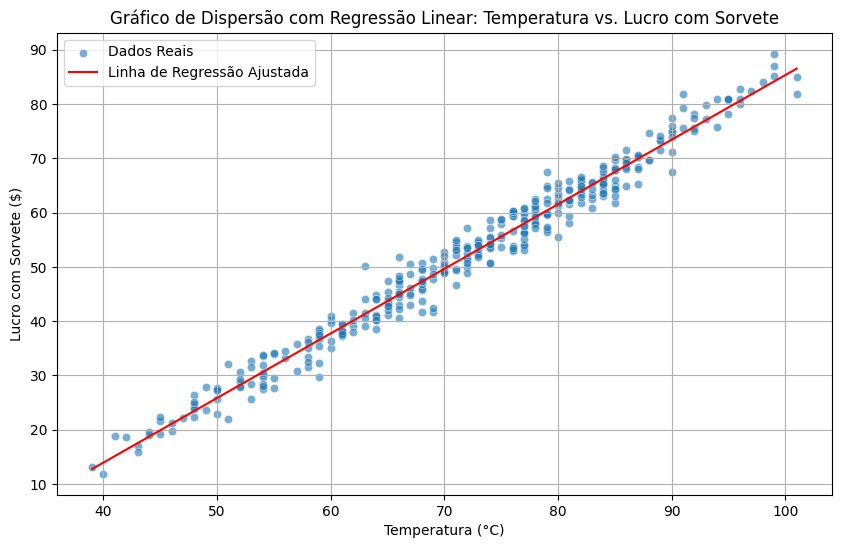

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Assegurar que 'df' está disponível no ambiente. (Já está, conforme o estado do kernel)

# Definir as features (X) e o target (y)
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Dividir os dados em conjuntos de treino e teste (necessário para o processo completo, mesmo que só o modelo treinado seja usado aqui)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo de Regressão Linear
model = LinearRegression()
model.fit(X_train, y_train)

# Criar o gráfico de dispersão com a linha de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Temperature'], y=df['Ice Cream Profits'], label='Dados Reais', alpha=0.6)

# Adicionar a linha de regressão usando o modelo treinado
plt.plot(X, model.predict(X), color='red', label='Linha de Regressão Ajustada')

plt.title('Gráfico de Dispersão com Regressão Linear: Temperatura vs. Lucro com Sorvete')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Lucro com Sorvete ($)')
plt.legend()
plt.grid(True)
plt.show()